# 所有数学曲线汇总

这个 notebook 用 Matplotlib 绘制项目中已经出现过的数学曲线，并补充一组常见平面曲线。

特点：

- 所有曲线集中在一个 `curves` 列表里，方便增删和调整参数。
- Notebook 不保存运行输出，文件更小，重新运行即可生成图像。
- 既包含笛卡尔参数方程，也包含极坐标曲线转笛卡尔坐标。


## 曲线清单

圆、椭圆、抛物线、双曲线、心脏线、蚶线、伯努利双纽线、阿基米德螺旋、对数螺旋、费马螺旋、玫瑰线、李萨如曲线、摆线、外摆线、内摆线、星形线、三尖瓣线、肾形线、蝴蝶曲线、西奥多罗斯螺旋、欧拉螺旋、追踪曲线、悬链线、阿涅西的女巫、蔓叶线、尼科米德斯蚌线。


In [15]:
import math
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.unicode_minus'] = False


In [16]:
def polar_to_xy(theta, r):
    return r * np.cos(theta), r * np.sin(theta)


def finite_xy(x, y):
    mask = np.isfinite(x) & np.isfinite(y)
    return x[mask], y[mask]


def clothoid_xy(t):
    # Numerical Euler spiral: x = int cos(u^2) du, y = int sin(u^2) du.
    du = np.gradient(t)
    x = np.cumsum(np.cos(t**2) * du)
    y = np.cumsum(np.sin(t**2) * du)
    return x - x.mean(), y - y.mean()


def theodorus_xy(n=18):
    x = [0.0, 1.0]
    y = [0.0, 0.0]
    angle = 0.0
    for k in range(1, n + 1):
        angle += math.atan(1 / math.sqrt(k))
        radius = math.sqrt(k + 1)
        x.append(radius * math.cos(angle))
        y.append(radius * math.sin(angle))
    return np.array(x), np.array(y)


In [17]:
theta = np.linspace(0, 2 * np.pi, 2000)
theta_long = np.linspace(0, 12 * np.pi, 3000)
x_line = np.linspace(-4, 4, 2000)
t_line = np.linspace(-3, 3, 2000)
t_pos = np.linspace(0.05, 5, 2000)

curves = []

curves.append({
    'name': 'Circle',# 圆
    'equation': 'x = cos(t), y = sin(t)',
    'xy': (np.cos(theta), np.sin(theta)),
})

curves.append({
    'name': 'Ellipse',# 椭圆
    'equation': 'x = 2cos(t), y = sin(t)',
    'xy': (2 * np.cos(theta), np.sin(theta)),
})

curves.append({
    'name': 'Parabola',# 抛物线
    'equation': 'y = x^2 / 2',
    'xy': (x_line, x_line**2 / 2),
})

x_h = np.r_[np.linspace(-4, -0.15, 1000), np.nan, np.linspace(0.15, 4, 1000)]
curves.append({
    'name': 'Rectangular Hyperbola', # 等轴双曲线
    'equation': 'y = 1 / x',
    'xy': (x_h, 1 / x_h),
})

curves.append({
    'name': 'Cardioid',# 心脏线
    'equation': 'r = 1 - cos(theta)',
    'xy': polar_to_xy(theta, 1 - np.cos(theta)),
})

curves.append({
    'name': 'Cardioid',# 心形线
    'equation': 'r = 1 - sin(theta)',
    'xy': polar_to_xy(theta, 1 - np.sin(theta)),
})

curves.append({
    'name': 'Limacon',# 蚶线
    'equation': 'r = 1 + 0.45cos(theta)',
    'xy': polar_to_xy(theta, 1 + 0.45 * np.cos(theta)),
})

r2 = np.cos(2 * theta)
r = np.where(r2 >= 0, np.sqrt(np.abs(r2)), np.nan)
curves.append({
    'name': 'Lemniscate',# 伯努利双纽线
    'equation': 'r^2 = cos(2theta)',
    'xy': polar_to_xy(theta, r),
})

curves.append({
    'name': 'Archimedean Spiral',# 阿基米德螺旋
    'equation': 'r = 0.12theta',
    'xy': polar_to_xy(theta_long, 0.12 * theta_long),
})

curves.append({
    'name': 'Logarithmic Spiral',# 对数螺旋
    'equation': 'r = exp(0.11theta)',
    'xy': polar_to_xy(np.linspace(0, 8 * np.pi, 2500), np.exp(0.11 * np.linspace(0, 8 * np.pi, 2500))),
})

u = np.linspace(0, 35, 2500)
curves.append({
    'name': 'Fermat Spiral',# 费马螺旋
    'equation': 'r = sqrt(theta)',
    'xy': polar_to_xy(u, np.sqrt(u)),
})

curves.append({
    'name': 'Rose / Rhodonea',# 玫瑰线
    'equation': 'r = 5sin(2theta)',
    'xy': polar_to_xy(theta, 5 * np.sin(2 * theta)),
})

curves.append({
    'name': 'Lissajous',# 李萨如曲线
    'equation': 'x = sin(3t + pi/2), y = sin(2t)',
    'xy': (np.sin(3 * theta + np.pi / 2), np.sin(2 * theta)),
})

t_c = np.linspace(0, 4 * np.pi, 2000)
curves.append({
    'name': 'Cycloid',# 摆线
    'equation': 'x = t - sin(t), y = 1 - cos(t)',
    'xy': (t_c - np.sin(t_c), 1 - np.cos(t_c)),
    'equal': False,
})

R, rr = 4, 1
curves.append({
    'name': 'Epicycloid',# 外摆线
    'equation': 'R = 4, r = 1',
    'xy': ((R + rr) * np.cos(theta) - rr * np.cos((R + rr) / rr * theta), (R + rr) * np.sin(theta) - rr * np.sin((R + rr) / rr * theta)),
})

R, rr = 5, 1
curves.append({
    'name': 'Hypocycloid',# 内摆线
    'equation': 'R = 5, r = 1',
    'xy': ((R - rr) * np.cos(theta) + rr * np.cos((R - rr) / rr * theta), (R - rr) * np.sin(theta) - rr * np.sin((R - rr) / rr * theta)),
})

curves.append({
    'name': 'Astroid',# 星形线
    'equation': 'x = 4cos^3(t), y = 4sin^3(t)',
    'xy': (4 * np.cos(theta)**3, 4 * np.sin(theta)**3),
})

R, rr = 3, 1
curves.append({
    'name': 'Deltoid',# 三尖瓣线
    'equation': 'hypocycloid, R = 3, r = 1',
    'xy': ((R - rr) * np.cos(theta) + rr * np.cos((R - rr) / rr * theta), (R - rr) * np.sin(theta) - rr * np.sin((R - rr) / rr * theta)),
})

R, rr = 2, 1
curves.append({
    'name': 'Nephroid',# 肾形线
    'equation': 'epicycloid, R = 2, r = 1',
    'xy': ((R + rr) * np.cos(theta) - rr * np.cos((R + rr) / rr * theta), (R + rr) * np.sin(theta) - rr * np.sin((R + rr) / rr * theta)),
})

tb = np.linspace(0, 12 * np.pi, 3000)
rb = np.exp(np.cos(tb)) - 2 * np.cos(4 * tb) + np.sin(tb / 12)**5
curves.append({
    'name': 'Butterfly Curve',# 蝴蝶曲线
    'equation': 'r = e^cos(t) - 2cos(4t) + sin^5(t/12)',
    'xy': polar_to_xy(tb, rb),
})

curves.append({
    'name': 'Spiral of Theodorus',# 西奥多罗斯螺旋
    'equation': 'right-triangle spiral',
    'xy': theodorus_xy(20),
})

tc = np.linspace(-4, 4, 3000)
curves.append({
    'name': 'Clothoid',# 欧拉螺旋
    'equation': 'numerical Fresnel integral',
    'xy': clothoid_xy(tc),
})

curves.append({
    'name': 'Tractrix',# 追踪曲线
    'equation': 'x = t - tanh(t), y = sech(t)',
    'xy': (t_line - np.tanh(t_line), 1 / np.cosh(t_line)),
})

curves.append({
    'name': 'Catenary',# 悬链线
    'equation': 'y = cosh(x / 2)',
    'xy': (x_line, np.cosh(x_line / 2)),
    'equal': False,
})

curves.append({
    'name': 'Witch of Agnesi',# 阿涅西的女巫
    'equation': 'y = 8 / (x^2 + 4)',
    'xy': (x_line, 8 / (x_line**2 + 4)),
    'equal': False,
})

a = 1.0
x_ci = np.linspace(0.001, 3, 1600)
y_ci = np.sqrt(np.maximum(x_ci**3 / (2 * a - x_ci), 0))
curves.append({
    'name': 'Cissoid',# 蔓叶线
    'equation': 'y^2 = x^3 / (2a - x)',
    'xy': (np.r_[x_ci, x_ci[::-1]], np.r_[y_ci, -y_ci[::-1]]),
})

r_con = 1 / np.cos(theta) + 1.3
x_con, y_con = polar_to_xy(theta, r_con)
x_con, y_con = finite_xy(x_con, y_con)
curves.append({
    'name': 'Conchoid',# 尼科米德斯蚌线
    'equation': 'r = a sec(theta) + b',
    'xy': (x_con[np.abs(x_con) < 8], y_con[np.abs(x_con) < 8]),
    'equal': False,
})

len(curves)


27

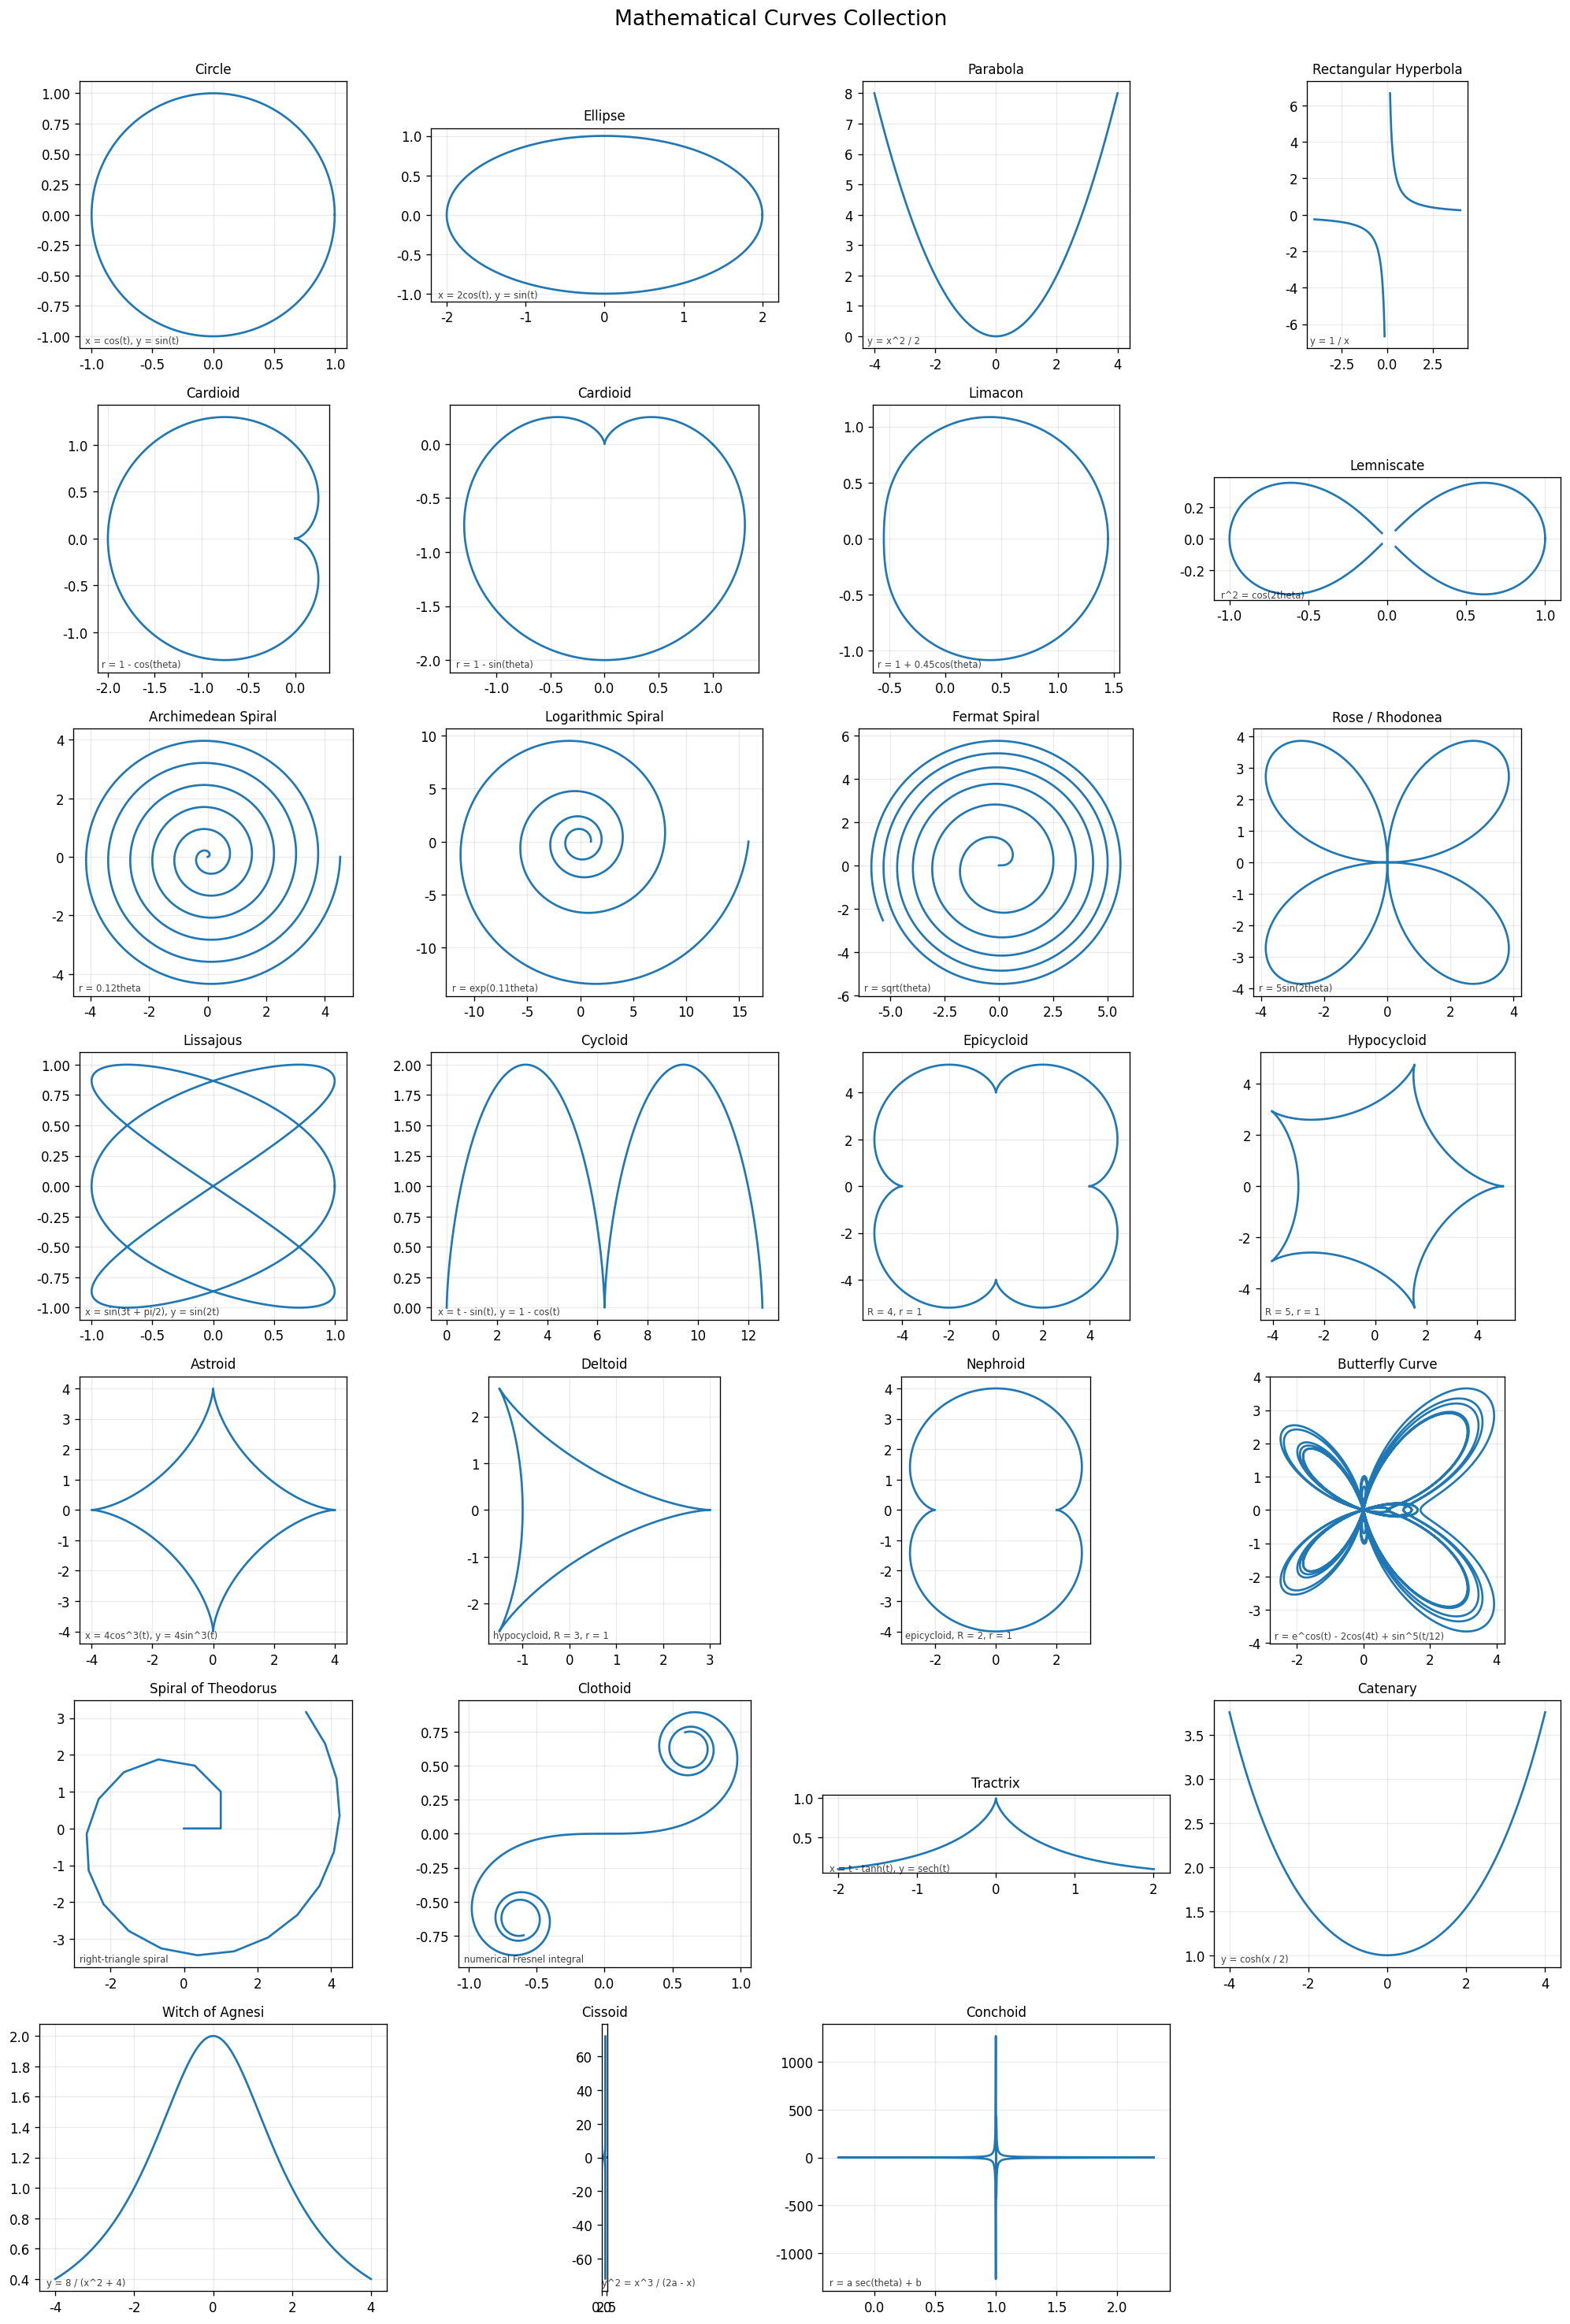

In [18]:
cols = 4
rows = math.ceil(len(curves) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(4.2 * cols, 3.5 * rows))
axes = axes.ravel()

for ax, curve in zip(axes, curves):
    x, y = curve['xy']
    ax.plot(x, y, linewidth=1.6)
    ax.set_title(curve['name'], fontsize=10)
    ax.text(0.02, 0.02, curve['equation'], transform=ax.transAxes, fontsize=7, alpha=0.75)
    if curve.get('equal', True):
        ax.set_aspect('equal', adjustable='box')
    ax.grid(True, alpha=0.25)

for ax in axes[len(curves):]:
    ax.axis('off')

fig.suptitle('Mathematical Curves Collection', fontsize=16, y=1.002)
fig.tight_layout()
plt.show()


## 单独查看某条曲线

修改 `curve_index` 可以单独放大查看任意一条曲线。


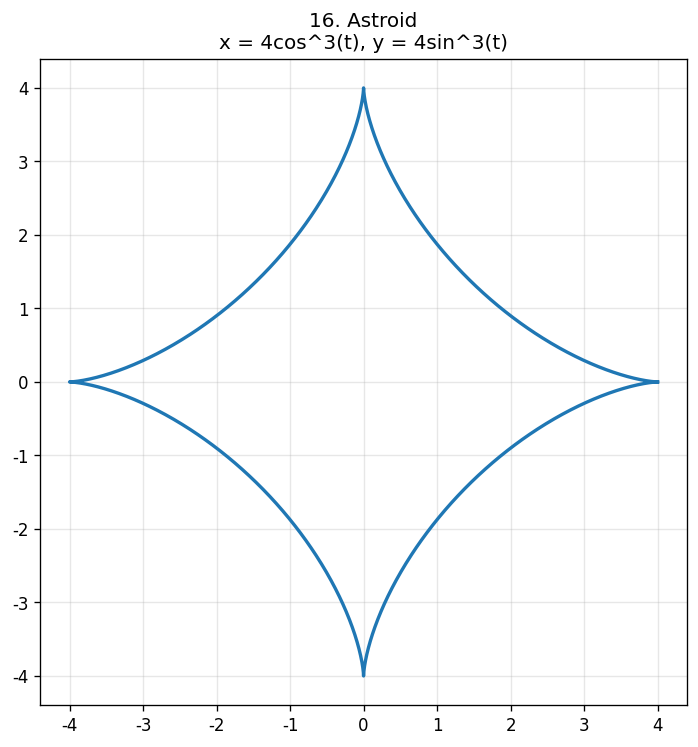

In [21]:
curve_index = 16
curve = curves[curve_index]
x, y = curve['xy']

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(x, y, linewidth=2)
ax.set_title(f"{curve_index}. {curve['name']}\n{curve['equation']}")
if curve.get('equal', True):
    ax.set_aspect('equal', adjustable='box')
ax.grid(True, alpha=0.3)
plt.show()
